gapminder.tsv 파일 데이터 분석

In [1]:
# 필요한 모듈 임포트

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

*   파일을 읽고 DataFrame 생성
*   국가 수
*   대륙 수
*   연도 수
*   기대수명 분석
    * 기대수명 최댓값, 최솟값 행
*   1인당 GDP 분석
    * 1인당 GDP 최댓값, 최솟값 행
*   인구수 분석
*   그룹별 통계량 (대륙별 기대수명, 인구수, 1인당GDP평균, 연도별) + 그래프       


In [3]:
file_path='https://raw.githubusercontent.com/JakeOh/202511_BD53/refs/heads/main/datasets/gapminder.tsv'

In [4]:
gapm=pd.read_csv(file_path,sep='\t')

In [5]:
gapm

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


## 국가수

In [6]:
gapm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


In [7]:
gapm.country.value_counts()

,count
country,
Afghanistan,12
Albania,12
Algeria,12
Angola,12
Argentina,12
...,...
Vietnam,12
West Bank and Gaza,12
"Yemen, Rep.",12


In [8]:
nara=gapm.country.unique()

In [9]:
nara.size

142

## 대륙수

In [10]:
daeryuk=gapm.continent.unique()

In [11]:
daeryuk.size

5

## 년도수

In [12]:
gapm.year.value_counts()

,count
year,
1952,142
1957,142
1962,142
1967,142
1972,142
1977,142
1982,142
1987,142
1992,142


In [13]:
ear=gapm.year.unique()

In [14]:
ear.size

12

In [15]:
ss=gapm.year.max()

In [16]:
dd=gapm.year.min()

In [17]:
print(ss,dd)

2007 1952


## 기대수명(lifeExp)분석

In [18]:
gapm.lifeExp.max()

82.603

In [19]:
gapm[gapm.lifeExp==gapm.lifeExp.max()]

,country,continent,year,lifeExp,pop,gdpPercap
803,Japan,Asia,2007,82.603,127467972,31656.06806


In [20]:
gapm[gapm.lifeExp==gapm.lifeExp.min()]

,country,continent,year,lifeExp,pop,gdpPercap
1292,Rwanda,Africa,1992,23.599,7290203,737.068595


# 1인당 GDP(gdpPercap) 분석

In [21]:
gapm[gapm.gdpPercap==gapm.gdpPercap.max()] # 1인당GDP가최대인행

,country,continent,year,lifeExp,pop,gdpPercap
853,Kuwait,Asia,1957,58.033,212846,113523.1329


## 쿠웨이트의 1인당 GDP 변화

In [22]:
kuwa=gapm[gapm.country=='Kuwait']

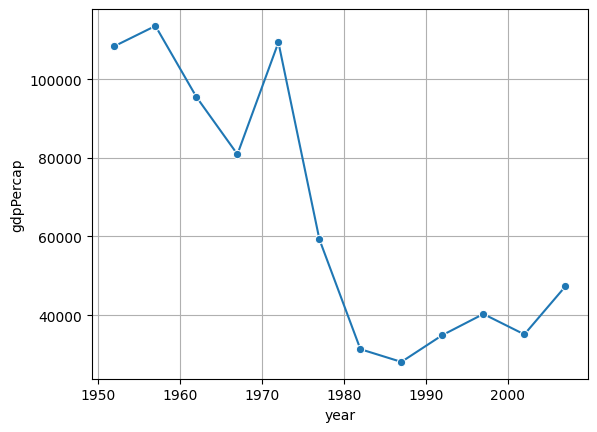

In [23]:
sns.lineplot(data=kuwa,x='year',y='gdpPercap',marker='o')
plt.grid()
plt.show()

## 콩고의 1인당 GDP 변화

In [24]:
gapm[gapm.gdpPercap==gapm.gdpPercap.min()] # 1인당GDP가최소인행

,country,continent,year,lifeExp,pop,gdpPercap
334,"Congo, Dem. Rep.",Africa,2002,44.966,55379852,241.165876


In [25]:
congo=gapm[gapm.country=='Congo, Dem. Rep.']

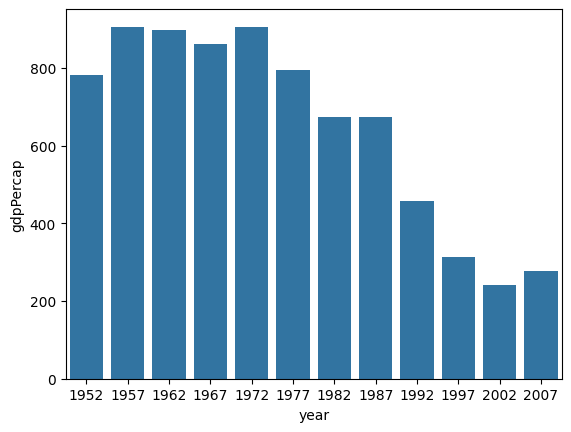

In [26]:
sns.barplot(data=congo,x='year',y='gdpPercap')

plt.show()

## 대륙별 1인당 GDP 평균의 연도별 변화

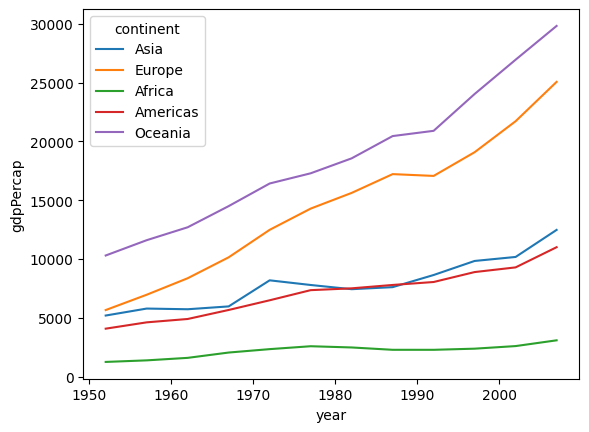

In [27]:
sns.lineplot(data=gapm, x='year',y='gdpPercap',hue='continent',errorbar=None)
plt.show()

In [28]:
gapm.groupby(by=['year','continent']).gdpPercap.mean()

year  continent
1952  Africa        1252.572466
      Americas      4079.062552
      Asia          5195.484004
      Europe        5661.057435
      Oceania      10298.085650
1957  Africa        1385.236062
      Americas      4616.043733
      Asia          5787.732940
      Europe        6963.012816
      Oceania      11598.522455
1962  Africa        1598.078825
      Americas      4901.541870
      Asia          5729.369625
      Europe        8365.486814
      Oceania      12696.452430
1967  Africa        2050.363801
      Americas      5668.253496
      Asia          5971.173374
      Europe       10143.823757
      Oceania      14495.021790
1972  Africa        2339.615674
      Americas      6491.334139
      Asia          8187.468699
      Europe       12479.575246
      Oceania      16417.333380
1977  Africa        2585.938508
      Americas      7352.007126
      Asia          7791.314020
      Europe       14283.979110
      Oceania      17283.957605
1982  Africa        2481.592960
      Americas      7506.737088
      Asia          7434.135157
      Europe       15617.896551
      Oceania      18554.709840
1987  Africa        2282.668991
      Americas      7793.400261
      Asia          7608.226508
      Europe       17214.310727
      Oceania      20448.040160
1992  Africa        2281.810333
      Americas      8044.934406
      Asia          8639.690248
      Europe       17061.568084
      Oceania      20894.045885
1997  Africa        2378.759555
      Americas      8889.300863
      Asia          9834.093295
      Europe       19076.781802
      Oceania      24024.175170
2002  Africa        2599.385159
      Americas      9287.677107
      Asia         10174.090397
      Europe       21711.732422
      Oceania      26938.778040
2007  Africa        3089.032605
      Americas     11003.031625
      Asia         12473.026870
      Europe       25054.481636
      Oceania      29810.188275
Name: gdpPercap, dtype: float64

## 2007년 1인당 GDP 상위 10개 국가

In [29]:
# sang=gapm[gapm.year==2007].gdpPercap.sort_values(ascending=False).head(n=10)
# sang

sang=gapm[gapm.year==2007].sort_values(by='gdpPercap',ascending=False).head(n=10)
sang

,country,continent,year,lifeExp,pop,gdpPercap
1151,Norway,Europe,2007,80.196,4627926,49357.19017
863,Kuwait,Asia,2007,77.588,2505559,47306.98978
1367,Singapore,Asia,2007,79.972,4553009,47143.17964
1619,United States,Americas,2007,78.242,301139947,42951.65309
755,Ireland,Europe,2007,78.885,4109086,40675.99635
671,"Hong Kong, China",Asia,2007,82.208,6980412,39724.97867
1487,Switzerland,Europe,2007,81.701,7554661,37506.41907
1091,Netherlands,Europe,2007,79.762,16570613,36797.93332
251,Canada,Americas,2007,80.653,33390141,36319.23501
695,Iceland,Europe,2007,81.757,301931,36180.78919


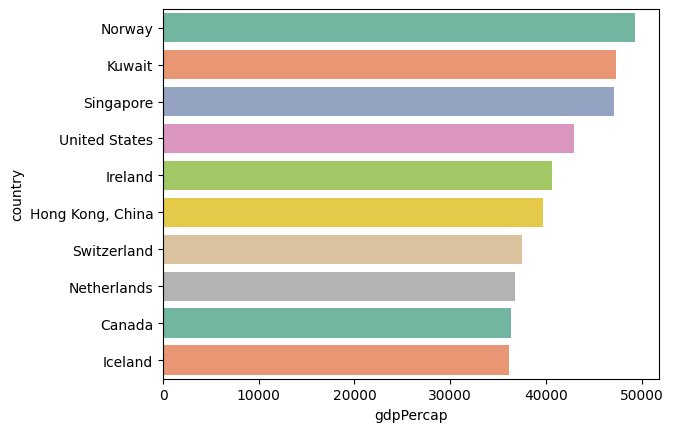

In [30]:
sns.barplot(data=sang, y='country' ,x='gdpPercap',hue='country',palette='Set2')
plt.show()

## 2007년 1인당 GDP 하위 10개 국가

In [31]:
ha=gapm[gapm.year==2007].sort_values(by='gdpPercap').head(n=10)
ha

,country,continent,year,lifeExp,pop,gdpPercap
335,"Congo, Dem. Rep.",Africa,2007,46.462,64606759,277.551859
899,Liberia,Africa,2007,45.678,3193942,414.507341
215,Burundi,Africa,2007,49.580,8390505,430.070692
1703,Zimbabwe,Africa,2007,43.487,12311143,469.709298
635,Guinea-Bissau,Africa,2007,46.388,1472041,579.231743
1127,Niger,Africa,2007,56.867,12894865,619.676892
503,Eritrea,Africa,2007,58.040,4906585,641.369524
515,Ethiopia,Africa,2007,52.947,76511887,690.805576
263,Central African Republic,Africa,2007,44.741,4369038,706.016537
563,Gambia,Africa,2007,59.448,1688359,752.749726


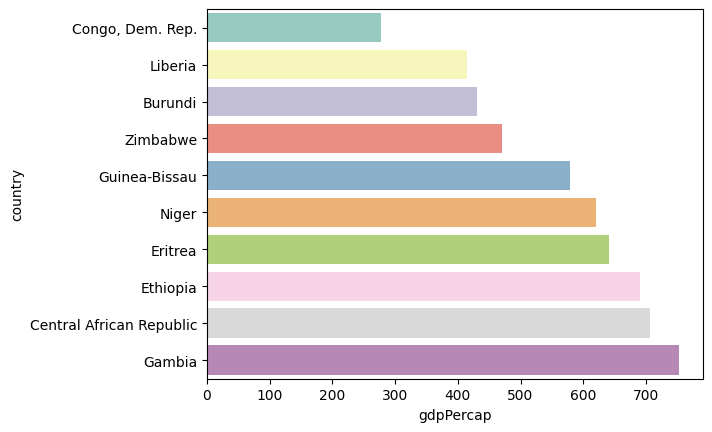

In [32]:
sns.barplot(data=ha, y='country' ,x='gdpPercap',hue='country',palette='Set3')
plt.show()

## 한국, 중국, 일본의 1인당 GDP 변화

In [33]:
dong=gapm[(gapm.country=='China') | (gapm.country=='Japan')| (gapm.country=='Korea, Rep.')]#.sort_values(by='gdpPercap').head(n=10)
# gapm[gapm.country=='Japan']
# gapm[gapm.country=='Korea, Rep.']
dong

,country,continent,year,lifeExp,pop,gdpPercap
288,China,Asia,1952,44.00000,556263527,400.448611
289,China,Asia,1957,50.54896,637408000,575.987001
290,China,Asia,1962,44.50136,665770000,487.674018
291,China,Asia,1967,58.38112,754550000,612.705693
292,China,Asia,1972,63.11888,862030000,676.900092
293,China,Asia,1977,63.96736,943455000,741.237470
294,China,Asia,1982,65.52500,1000281000,962.421381
295,China,Asia,1987,67.27400,1084035000,1378.904018
296,China,Asia,1992,68.69000,1164970000,1655.784158
297,China,Asia,1997,70.42600,1230075000,2289.234136


In [34]:
cjk=['China','Japan','Korea, Rep.']
# cjk_df=gapm[(gapm.country=='China') | (gapm.country=='Japan')| (gapm.country=='Korea, Rep.')]
# cjk_df

cjk_df=gapm[gapm.country.isin(cjk)]
cjk_df

,country,continent,year,lifeExp,pop,gdpPercap
288,China,Asia,1952,44.00000,556263527,400.448611
289,China,Asia,1957,50.54896,637408000,575.987001
290,China,Asia,1962,44.50136,665770000,487.674018
291,China,Asia,1967,58.38112,754550000,612.705693
292,China,Asia,1972,63.11888,862030000,676.900092
293,China,Asia,1977,63.96736,943455000,741.237470
294,China,Asia,1982,65.52500,1000281000,962.421381
295,China,Asia,1987,67.27400,1084035000,1378.904018
296,China,Asia,1992,68.69000,1164970000,1655.784158
297,China,Asia,1997,70.42600,1230075000,2289.234136


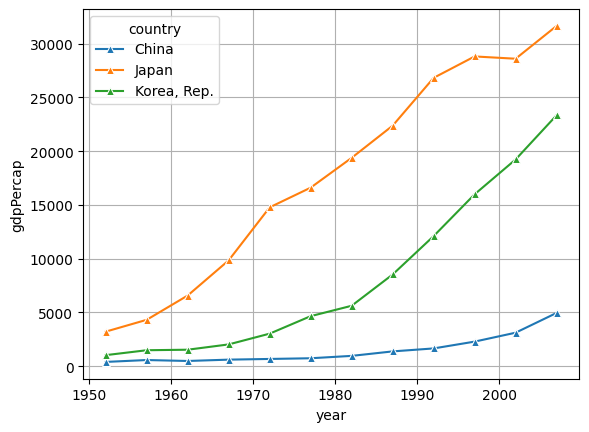

In [35]:
sns.lineplot(data=dong, x='year',y='gdpPercap',hue='country',marker='^')
plt.grid()
plt.show()

In [36]:
dong.groupby(by=['year','country']).gdpPercap.mean() #G7 gdp뽑기

year  country    
1952  China            400.448611
      Japan           3216.956347
      Korea, Rep.     1030.592226
1957  China            575.987001
      Japan           4317.694365
      Korea, Rep.     1487.593537
1962  China            487.674018
      Japan           6576.649461
      Korea, Rep.     1536.344387
1967  China            612.705693
      Japan           9847.788607
      Korea, Rep.     2029.228142
1972  China            676.900092
      Japan          14778.786360
      Korea, Rep.     3030.876650
1977  China            741.237470
      Japan          16610.377010
      Korea, Rep.     4657.221020
1982  China            962.421381
      Japan          19384.105710
      Korea, Rep.     5622.942464
1987  China           1378.904018
      Japan          22375.941890
      Korea, Rep.     8533.088805
1992  China           1655.784158
      Japan          26824.895110
      Korea, Rep.    12104.278720
1997  China           2289.234136
      Japan          28816.584990
      Korea, Rep.    15993.527960
2002  China           3119.280896
      Japan          28604.591900
      Korea, Rep.    19233.988180
2007  China           4959.114854
      Japan          31656.068060
      Korea, Rep.    23348.139730
Name: gdpPercap, dtype: float64

In [37]:
gapm[gapm['pop']==gapm['pop'].max()]

,country,continent,year,lifeExp,pop,gdpPercap
299,China,Asia,2007,72.961,1318683096,4959.114854


In [38]:
gapm[gapm['pop']==gapm['pop'].min()]

,country,continent,year,lifeExp,pop,gdpPercap
1296,Sao Tome and Principe,Africa,1952,46.471,60011,879.583586


## 대륙별 인구 변화

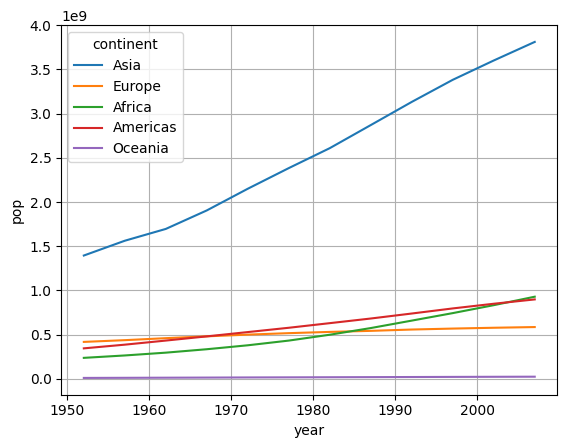

In [39]:
sns.lineplot(data=gapm,x='year',y='pop',hue='continent',errorbar=None,estimator='sum')
plt.grid()
plt.show()

In [40]:
gapm.groupby(by=['continent','year'])['pop'].sum()

continent  year
Africa     1952     237640501
           1957     264837738
           1962     296516865
           1967     335289489
           1972     379879541
           1977     433061021
           1982     499348587
           1987     574834110
           1992     659081517
           1997     743832984
           2002     833723916
           2007     929539692
Americas   1952     345152446
           1957     386953916
           1962     433270254
           1967     480746623
           1972     529384210
           1977     578067699
           1982     630290920
           1987     682753971
           1992     739274104
           1997     796900410
           2002     849772762
           2007     898871184
Asia       1952    1395357351
           1957    1562780599
           1962    1696357182
           1967    1905662900
           1972    2150972248
           1977    2384513556
           1982    2610135582
           1987    2871220762
           1992    3133292191
           1997    3383285500
           2002    3601802203
           2007    3811953827
Europe     1952     418120846
           1957     437890351
           1962     460355155
           1967     481178958
           1972     500635059
           1977     517164531
           1982     531266901
           1987     543094160
           1992     558142797
           1997     568944148
           2002     578223869
           2007     586098529
Oceania    1952      10686006
           1957      11941976
           1962      13283518
           1967      14600414
           1972      16106100
           1977      17239000
           1982      18394850
           1987      19574415
           1992      20919651
           1997      22241430
           2002      23454829
           2007      24549947
Name: pop, dtype: int64

아시아 대륙을 제외한 4개 대륙의 인구 변화

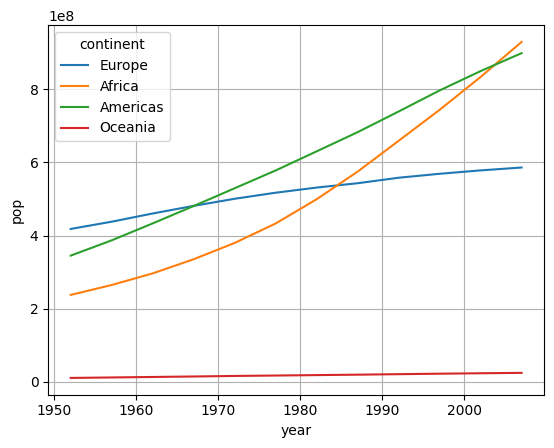

In [41]:
sns.lineplot(data=gapm[gapm.continent!='Asia'], x='year',y='pop',hue='continent',estimator='sum',errorbar=None)
plt.grid()
plt.show()

In [42]:
# # asian, eu, afri, ameri,ocea
# ohdae=['asian', 'eu', 'afri', 'ameri','ocea']
# ohdae_df=[gapm.continent.isin(ohdae)]
# ohdae_df

In [43]:
asian=gapm[gapm.continent=='Asia']
asian

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106
...,...,...,...,...,...,...
1675,"Yemen, Rep.",Asia,1987,52.922,11219340,1971.741538
1676,"Yemen, Rep.",Asia,1992,55.599,13367997,1879.496673
1677,"Yemen, Rep.",Asia,1997,58.020,15826497,2117.484526
1678,"Yemen, Rep.",Asia,2002,60.308,18701257,2234.820827


In [44]:
eu=gapm[gapm.continent=='Europe']
eu

,country,continent,year,lifeExp,pop,gdpPercap
12,Albania,Europe,1952,55.230,1282697,1601.056136
13,Albania,Europe,1957,59.280,1476505,1942.284244
14,Albania,Europe,1962,64.820,1728137,2312.888958
15,Albania,Europe,1967,66.220,1984060,2760.196931
16,Albania,Europe,1972,67.690,2263554,3313.422188
...,...,...,...,...,...,...
1603,United Kingdom,Europe,1987,75.007,56981620,21664.787670
1604,United Kingdom,Europe,1992,76.420,57866349,22705.092540
1605,United Kingdom,Europe,1997,77.218,58808266,26074.531360
1606,United Kingdom,Europe,2002,78.471,59912431,29478.999190


In [45]:
gapm.continent.unique()

array(['Asia', 'Europe', 'Africa', 'Americas', 'Oceania'], dtype=object)

In [46]:
afri=gapm[gapm.continent=='Africa']
afri

,country,continent,year,lifeExp,pop,gdpPercap
24,Algeria,Africa,1952,43.077,9279525,2449.008185
25,Algeria,Africa,1957,45.685,10270856,3013.976023
26,Algeria,Africa,1962,48.303,11000948,2550.816880
27,Algeria,Africa,1967,51.407,12760499,3246.991771
28,Algeria,Africa,1972,54.518,14760787,4182.663766
...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623


In [47]:
ameri=gapm[gapm.continent=='Americas']
ameri

,country,continent,year,lifeExp,pop,gdpPercap
48,Argentina,Americas,1952,62.485,17876956,5911.315053
49,Argentina,Americas,1957,64.399,19610538,6856.856212
50,Argentina,Americas,1962,65.142,21283783,7133.166023
51,Argentina,Americas,1967,65.634,22934225,8052.953021
52,Argentina,Americas,1972,67.065,24779799,9443.038526
...,...,...,...,...,...,...
1639,Venezuela,Americas,1987,70.190,17910182,9883.584648
1640,Venezuela,Americas,1992,71.150,20265563,10733.926310
1641,Venezuela,Americas,1997,72.146,22374398,10165.495180
1642,Venezuela,Americas,2002,72.766,24287670,8605.047831


In [48]:
ocea=gapm[gapm.continent=='Oceania']
ocea

,country,continent,year,lifeExp,pop,gdpPercap
60,Australia,Oceania,1952,69.120,8691212,10039.59564
61,Australia,Oceania,1957,70.330,9712569,10949.64959
62,Australia,Oceania,1962,70.930,10794968,12217.22686
63,Australia,Oceania,1967,71.100,11872264,14526.12465
64,Australia,Oceania,1972,71.930,13177000,16788.62948
65,Australia,Oceania,1977,73.490,14074100,18334.19751
66,Australia,Oceania,1982,74.740,15184200,19477.00928
67,Australia,Oceania,1987,76.320,16257249,21888.88903
68,Australia,Oceania,1992,77.560,17481977,23424.76683
69,Australia,Oceania,1997,78.830,18565243,26997.93657


In [49]:
ocea.describe()

,year,lifeExp,pop,gdpPercap
count,24.000000,24.000000,2.400000e+01,24.000000
mean,1979.500000,74.326208,8.874672e+06,18621.609223
std,17.631494,3.795611,6.506342e+06,6358.983321
min,1952.000000,69.120000,1.994794e+06,10039.595640
25%,1965.750000,71.205000,3.199212e+06,14141.858697
50%,1979.500000,73.665000,6.403492e+06,17983.303955
75%,1993.250000,77.552500,1.435162e+07,22214.117110
max,2007.000000,81.235000,2.043418e+07,34435.367440


In [50]:
ameri.describe() # life고공행진 gdp폭발

,year,lifeExp,pop,gdpPercap
count,300.000000,300.000000,3.000000e+02,300.000000
mean,1979.500000,64.658737,2.450479e+07,7136.110356
std,17.289102,9.345088,5.097943e+07,6396.764112
min,1952.000000,37.579000,6.628500e+05,1201.637154
25%,1965.750000,58.410000,2.962359e+06,3427.779072
50%,1979.500000,67.048000,6.227510e+06,5465.509853
75%,1993.250000,71.699500,1.834031e+07,7830.210416
max,2007.000000,80.653000,3.011399e+08,42951.653090


In [51]:
afri.describe() #gdp폭발 나이폭증

,year,lifeExp,pop,gdpPercap
count,624.00000,624.00000,6.240000e+02,624.000000
mean,1979.50000,48.86533,9.916003e+06,2193.754578
std,17.27411,9.15021,1.549092e+07,2827.929863
min,1952.00000,23.59900,6.001100e+04,241.165876
25%,1965.75000,42.37250,1.342075e+06,761.247010
50%,1979.50000,47.79200,4.579311e+06,1192.138217
75%,1993.25000,54.41150,1.080149e+07,2377.417422
max,2007.00000,76.44200,1.350312e+08,21951.211760


In [52]:
eu.describe() # 지디피폭발

,year,lifeExp,pop,gdpPercap
count,360.000000,360.000000,3.600000e+02,360.000000
mean,1979.500000,71.903686,1.716976e+07,14469.475533
std,17.284285,5.433178,2.051944e+07,9355.213498
min,1952.000000,43.585000,1.479620e+05,973.533195
25%,1965.750000,69.570000,4.331500e+06,7213.085037
50%,1979.500000,72.241000,8.551125e+06,12081.749115
75%,1993.250000,75.450500,2.180287e+07,20461.386162
max,2007.000000,81.757000,8.240100e+07,49357.190170


In [53]:
asian.describe() # 지디피폭발 나이폭증

,year,lifeExp,pop,gdpPercap
count,396.000000,396.000000,3.960000e+02,396.000000
mean,1979.500000,60.064903,7.703872e+07,7902.150428
std,17.282097,11.864532,2.068852e+08,14045.373112
min,1952.000000,28.801000,1.204470e+05,331.000000
25%,1965.750000,51.426250,3.844393e+06,1056.993223
50%,1979.500000,61.791500,1.453083e+07,2646.786844
75%,1993.250000,69.505250,4.630035e+07,8549.255654
max,2007.000000,82.603000,1.318683e+09,113523.132900


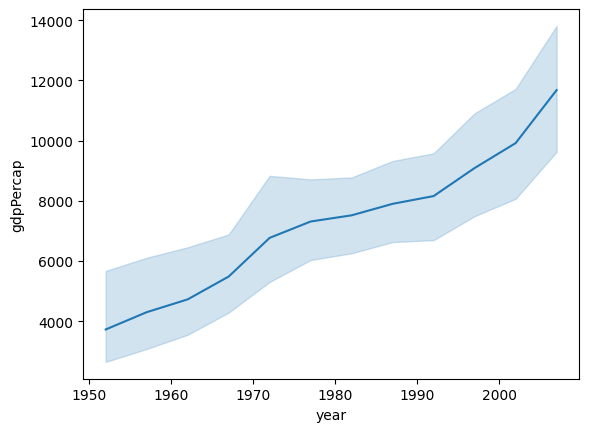

In [54]:
sns.lineplot(data=gapm,x='year',y='gdpPercap')
plt.show()

In [55]:
jp=gapm[gapm.country=='Japan']
jp

,country,continent,year,lifeExp,pop,gdpPercap
792,Japan,Asia,1952,63.030,86459025,3216.956347
793,Japan,Asia,1957,65.500,91563009,4317.694365
794,Japan,Asia,1962,68.730,95831757,6576.649461
795,Japan,Asia,1967,71.430,100825279,9847.788607
796,Japan,Asia,1972,73.420,107188273,14778.786360
797,Japan,Asia,1977,75.380,113872473,16610.377010
798,Japan,Asia,1982,77.110,118454974,19384.105710
799,Japan,Asia,1987,78.670,122091325,22375.941890
800,Japan,Asia,1992,79.360,124329269,26824.895110
801,Japan,Asia,1997,80.690,125956499,28816.584990


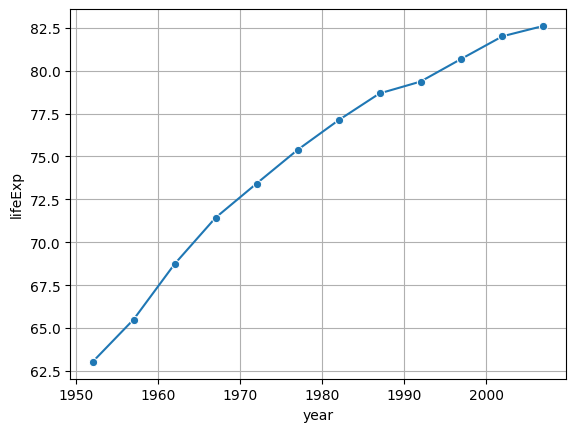

In [56]:
sns.lineplot(data=jp, x='year', y='lifeExp', marker='o')
plt.grid()
plt.show()

In [57]:
rwan=gapm[gapm.country=='Rwanda']
rwan

,country,continent,year,lifeExp,pop,gdpPercap
1284,Rwanda,Africa,1952,40.000,2534927,493.323875
1285,Rwanda,Africa,1957,41.500,2822082,540.289398
1286,Rwanda,Africa,1962,43.000,3051242,597.473073
1287,Rwanda,Africa,1967,44.100,3451079,510.963714
1288,Rwanda,Africa,1972,44.600,3992121,590.580664
1289,Rwanda,Africa,1977,45.000,4657072,670.080601
1290,Rwanda,Africa,1982,46.218,5507565,881.570647
1291,Rwanda,Africa,1987,44.020,6349365,847.991217
1292,Rwanda,Africa,1992,23.599,7290203,737.068595
1293,Rwanda,Africa,1997,36.087,7212583,589.944505


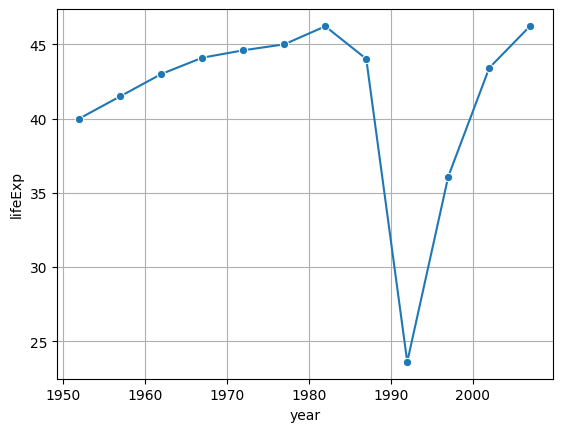

In [58]:
sns.lineplot(data=rwan, x='year', y='lifeExp', marker='o')
plt.grid()
plt.show()

## 기술통계량

In [59]:
gapm.describe()

,year,lifeExp,pop,gdpPercap
count,1704.00000,1704.000000,1.704000e+03,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081
std,17.26533,12.917107,1.061579e+08,9857.454543
min,1952.00000,23.599000,6.001100e+04,241.165876
25%,1965.75000,48.198000,2.793664e+06,1202.060309
50%,1979.50000,60.712500,7.023596e+06,3531.846988
75%,1993.25000,70.845500,1.958522e+07,9325.462346
max,2007.00000,82.603000,1.318683e+09,113523.132900


In [60]:
gapm.gdpPercap.describe()

,gdpPercap
count,1704.000000
mean,7215.327081
std,9857.454543
min,241.165876
25%,1202.060309
50%,3531.846988
75%,9325.462346
max,113523.132900


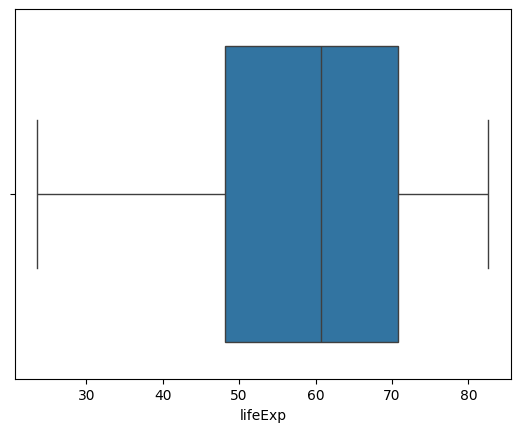

In [61]:
sns.boxplot(data=gapm,x='lifeExp')
plt.show()

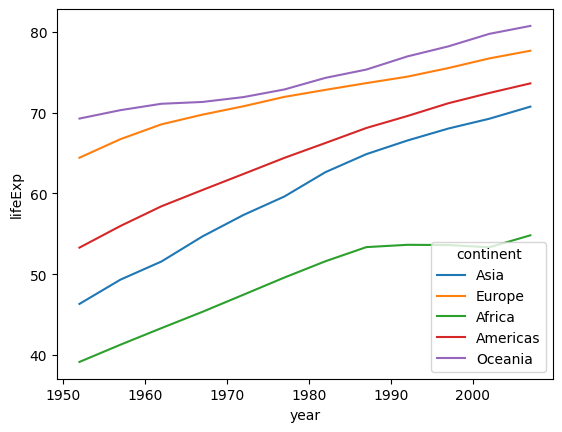

In [62]:
sns.lineplot(data=gapm, x='year',y='lifeExp',hue='continent',errorbar=None)
plt.show()

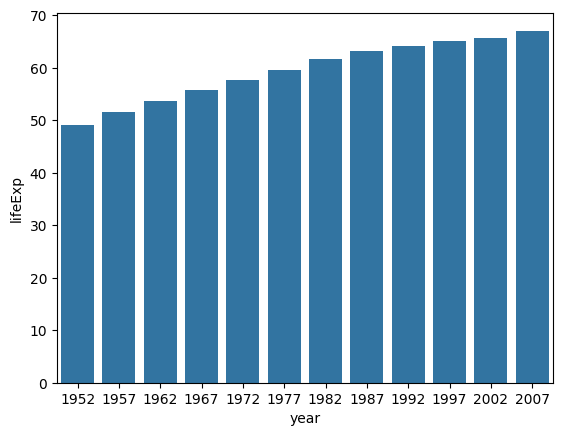

In [63]:
sns.barplot(data=gapm, x='year',y='lifeExp',errorbar=None)
plt.show()

In [64]:
gapm.groupby(by=['year']).lifeExp.mean()

,lifeExp
year,
1952,49.057620
1957,51.507401
1962,53.609249
1967,55.678290
1972,57.647386
1977,59.570157
1982,61.533197
1987,63.212613
1992,64.160338


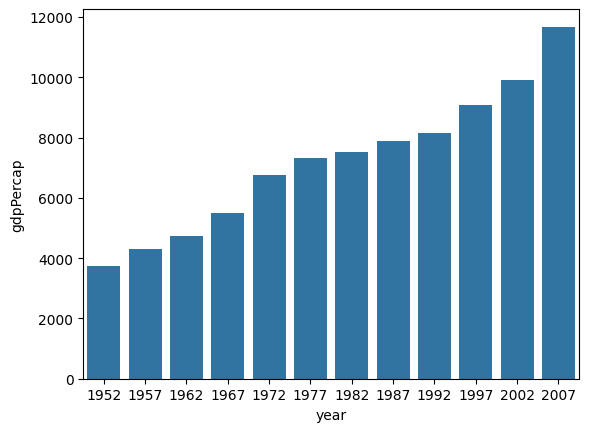

In [65]:
sns.barplot(data=gapm,y='gdpPercap',x='year',errorbar=None)
plt.show()

In [66]:
gapm.groupby(by=['year']).gdpPercap.mean()

,gdpPercap
year,
1952,3725.276046
1957,4299.408345
1962,4725.812342
1967,5483.653047
1972,6770.082815
1977,7313.166421
1982,7518.901673
1987,7900.920218
1992,8158.608521


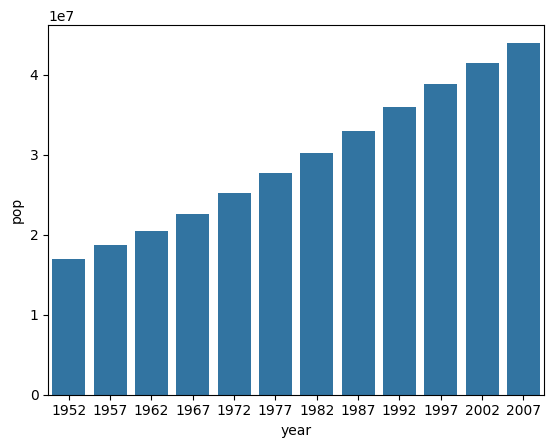

In [67]:
sns.barplot(data=gapm,y='pop',x='year',errorbar=None)
plt.show()

In [68]:
gapm.groupby(by=['year']).pop.mean()

,pop
year,
1952,1.695040e+07
1957,1.876341e+07
1962,2.042101e+07
1967,2.265830e+07
1972,2.518998e+07
1977,2.767638e+07
1982,3.020730e+07
1987,3.303857e+07
1992,3.599092e+07


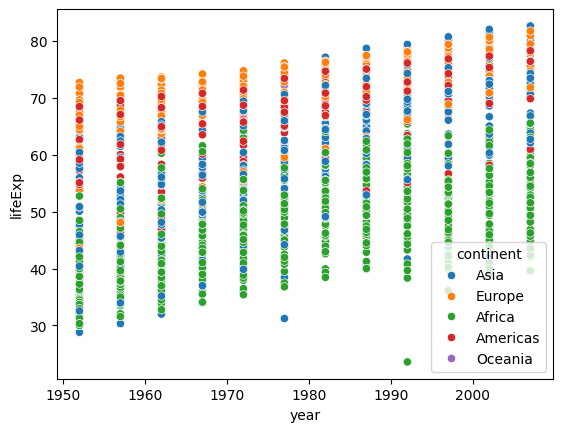

In [69]:
sns.scatterplot(data=gapm,x='year',y='lifeExp',hue='continent')
plt.show()

상관관계

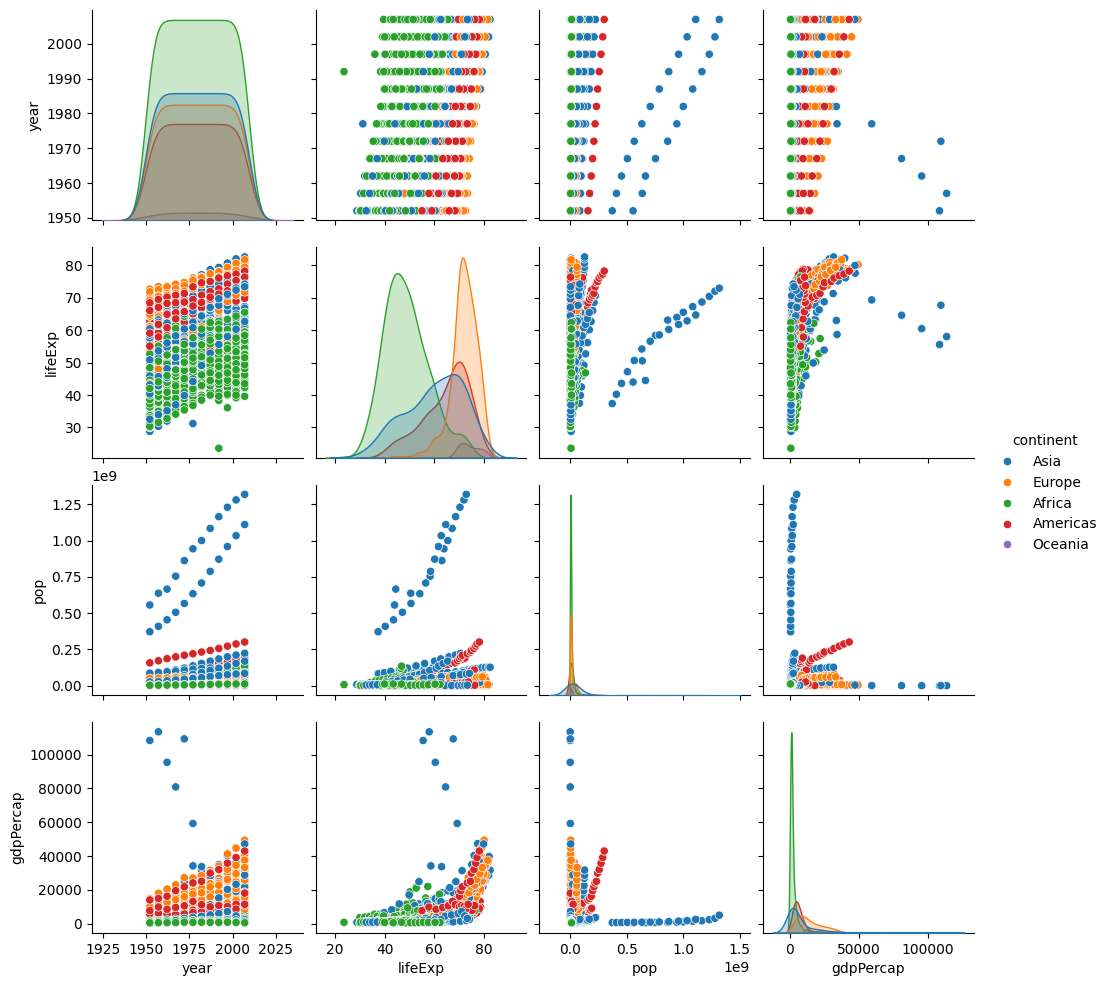

In [70]:
sns.pairplot(data=gapm,hue='continent')
plt.show()

In [71]:
gapm[['year','lifeExp','pop','gdpPercap'
]].corr() #상관계수

,year,lifeExp,pop,gdpPercap
year,1.000000,0.435611,0.082308,0.227318
lifeExp,0.435611,1.000000,0.064955,0.583706
pop,0.082308,0.064955,1.000000,-0.025600
gdpPercap,0.227318,0.583706,-0.025600,1.000000


## 2007년도 변수들 간의 상관관계

In [72]:
gapm_2007=gapm[gapm.year==2007]
gapm_2007

,country,continent,year,lifeExp,pop,gdpPercap
11,Afghanistan,Asia,2007,43.828,31889923,974.580338
23,Albania,Europe,2007,76.423,3600523,5937.029526
35,Algeria,Africa,2007,72.301,33333216,6223.367465
47,Angola,Africa,2007,42.731,12420476,4797.231267
59,Argentina,Americas,2007,75.320,40301927,12779.379640
...,...,...,...,...,...,...
1655,Vietnam,Asia,2007,74.249,85262356,2441.576404
1667,West Bank and Gaza,Asia,2007,73.422,4018332,3025.349798
1679,"Yemen, Rep.",Asia,2007,62.698,22211743,2280.769906
1691,Zambia,Africa,2007,42.384,11746035,1271.211593


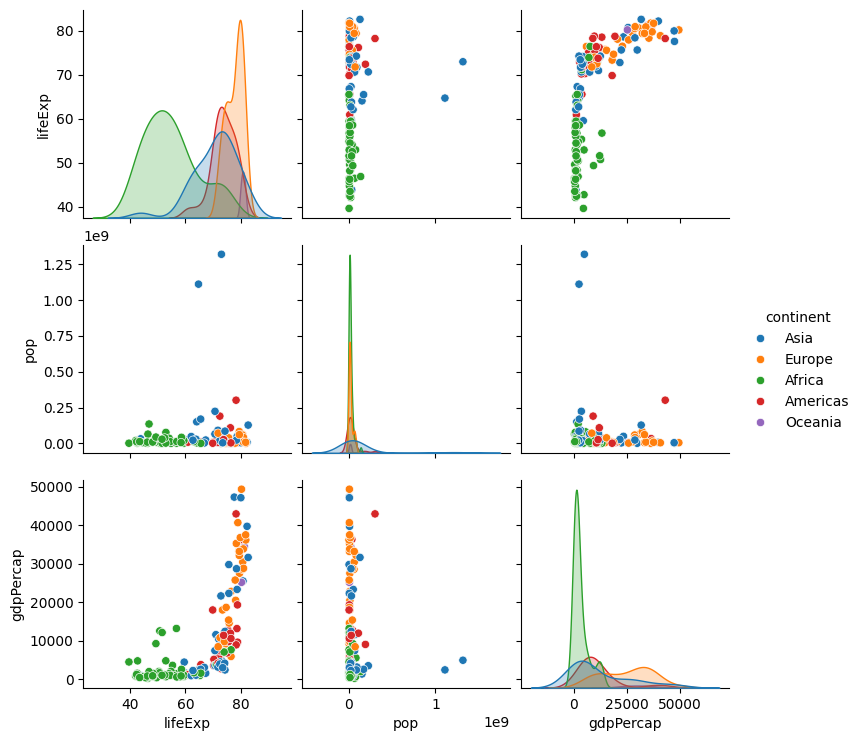

In [73]:
sns.pairplot(data=gapm_2007,vars=['lifeExp','pop','gdpPercap'],hue='continent')
plt.show()

In [74]:
gapm_2007[['lifeExp','pop','gdpPercap']].corr()

,lifeExp,pop,gdpPercap
lifeExp,1.000000,0.047553,0.678662
pop,0.047553,1.000000,-0.055676
gdpPercap,0.678662,-0.055676,1.000000


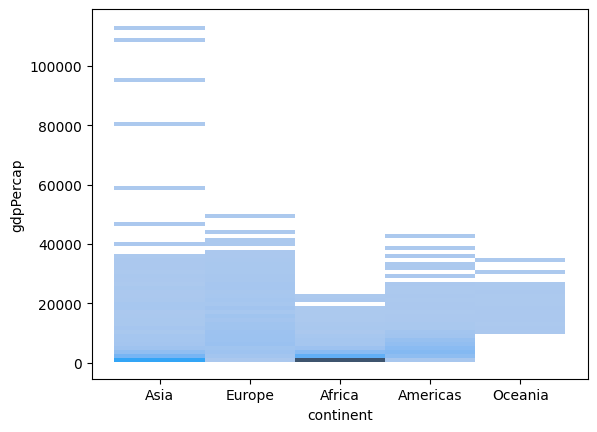

In [75]:
sns.histplot(data=gapm,x='continent',y='gdpPercap')
plt.show()

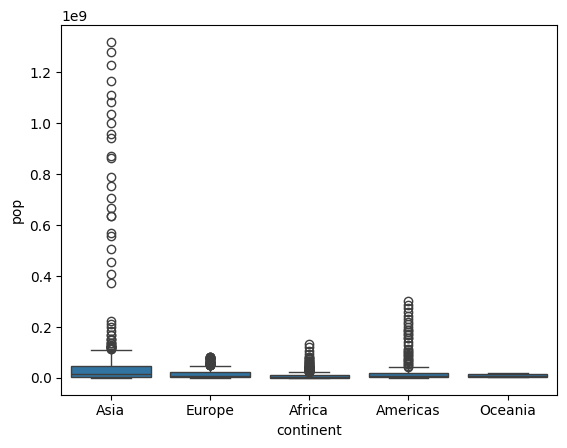

In [76]:
sns.boxplot(data=gapm, x='continent',y='pop')
plt.show()